# 1. Загрузка и первичный разведочный анализ

In [33]:
import pandas as pd
import numpy as np


dataSet = pd.read_csv('ai_student_impact_dataset.csv')

dataSet.info()
print(dataSet.isnull().sum())
# display(dataSet.head(35))
dataSet.describe()

categorical_cols = dataSet.select_dtypes(include=['str', 'category']).columns
print(f"Кол-во уникальных значений:\n{dataSet[categorical_cols].nunique()}")

for cat_col in categorical_cols:
  print(f"Уникальные значения для {cat_col}:\n{dataSet[cat_col].unique()}\n")

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

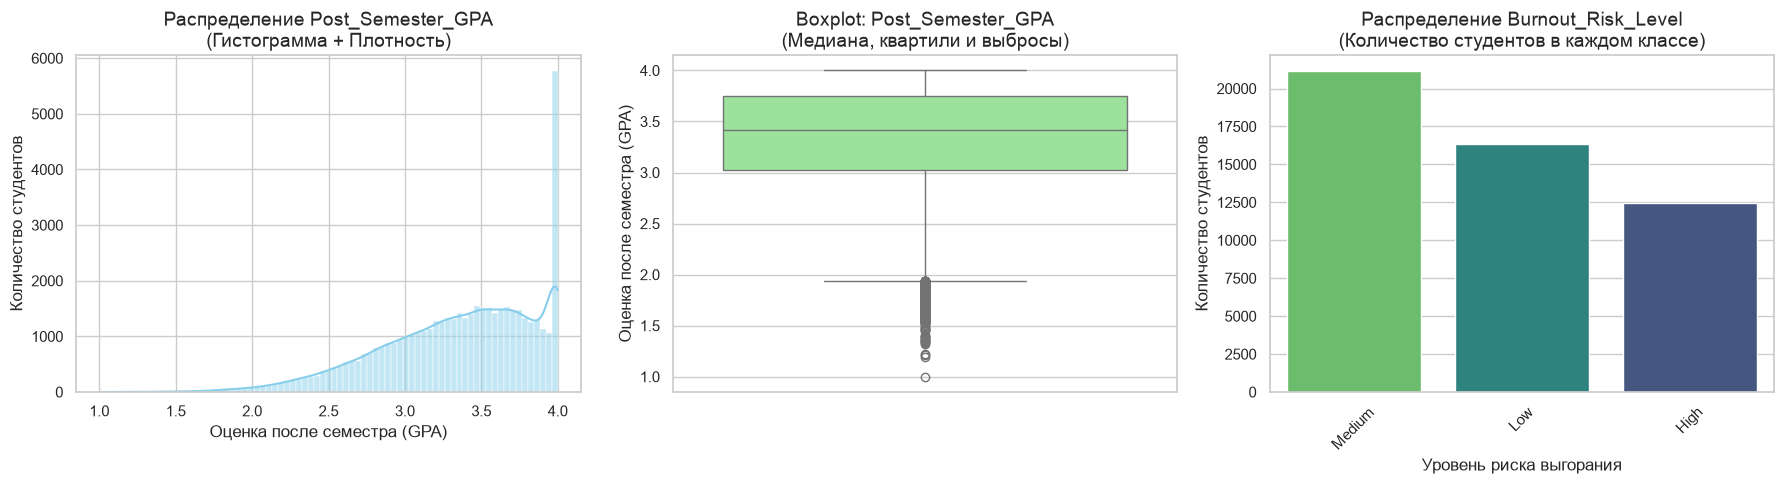

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=dataSet, x='Post_Semester_GPA', kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Распределение Post_Semester_GPA\n(Гистограмма + Плотность)', fontsize=14)
axes[0].set_xlabel('Оценка после семестра (GPA)', fontsize=12)
axes[0].set_ylabel('Количество студентов', fontsize=12)


sns.boxplot(data=dataSet, y='Post_Semester_GPA', color='lightgreen', ax=axes[1])
axes[1].set_title('Boxplot: Post_Semester_GPA\n(Медиана, квартили и выбросы)', fontsize=14)
axes[1].set_ylabel('Оценка после семестра (GPA)', fontsize=12)


sns.countplot(data=dataSet, x='Burnout_Risk_Level', hue='Burnout_Risk_Level', 
              palette='viridis', ax=axes[2], 
              order=dataSet['Burnout_Risk_Level'].value_counts().index, 
              legend=False)
axes[2].set_title('Распределение Burnout_Risk_Level\n(Количество студентов в каждом классе)', fontsize=14)
axes[2].set_xlabel('Уровень риска выгорания', fontsize=12)
axes[2].set_ylabel('Количество студентов', fontsize=12)

plt.setp(axes[2].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

Post_Semester_GPA:
 - Распределение не нормальное, есть выбросы
 - Нужно обработать выбросы

Burnout_Risk_Level:
 - Есть дисбаланс классов

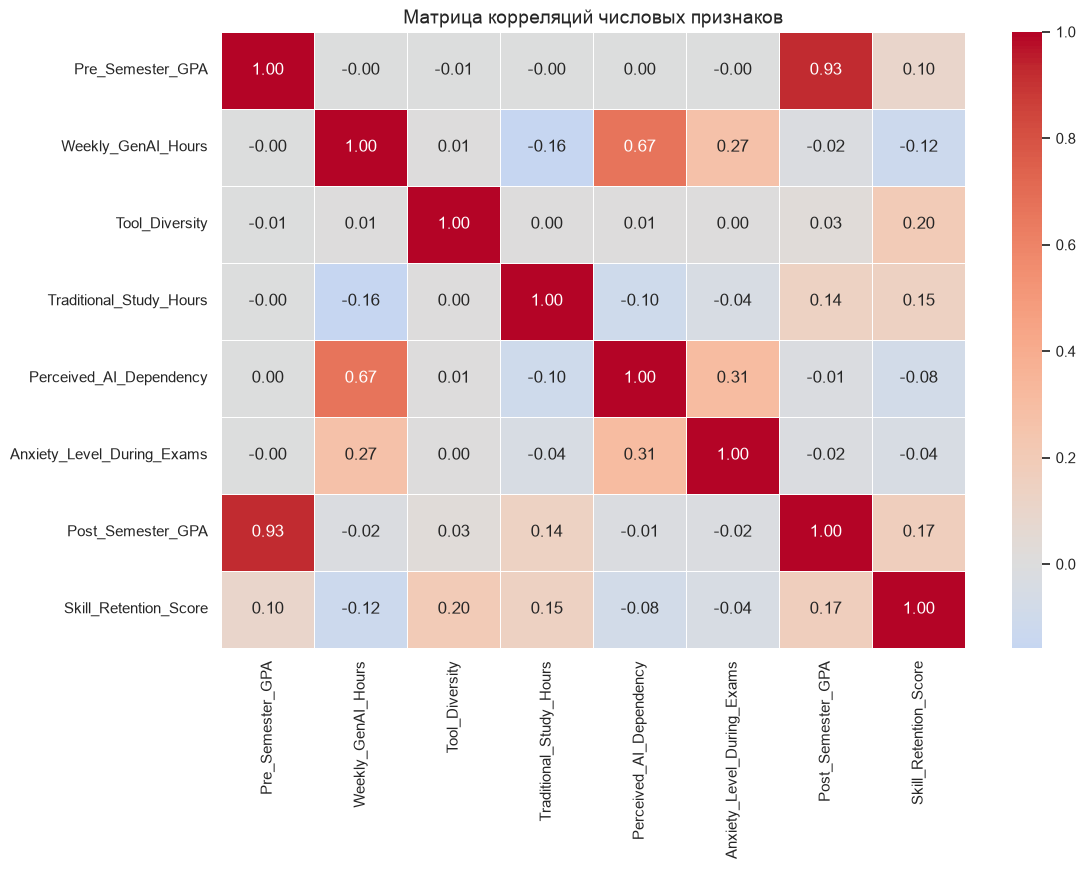

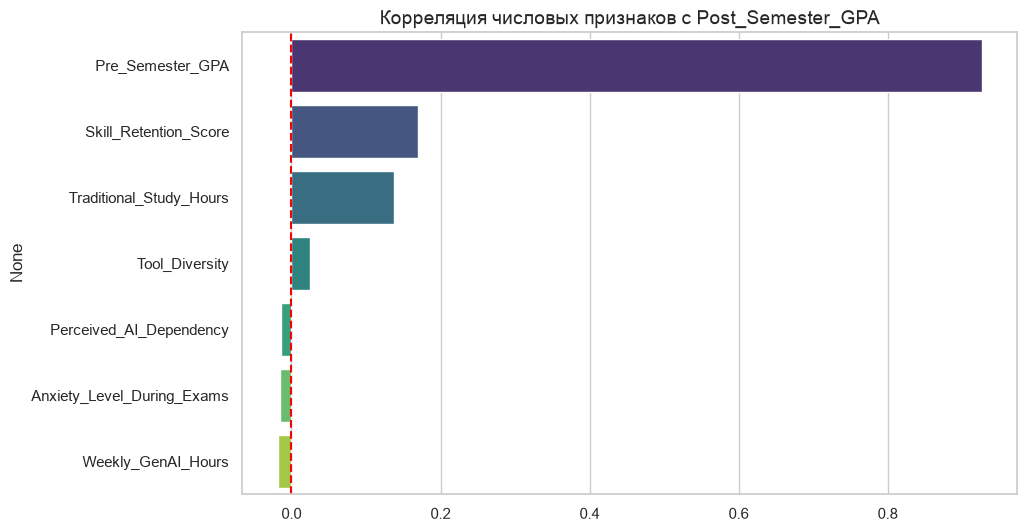

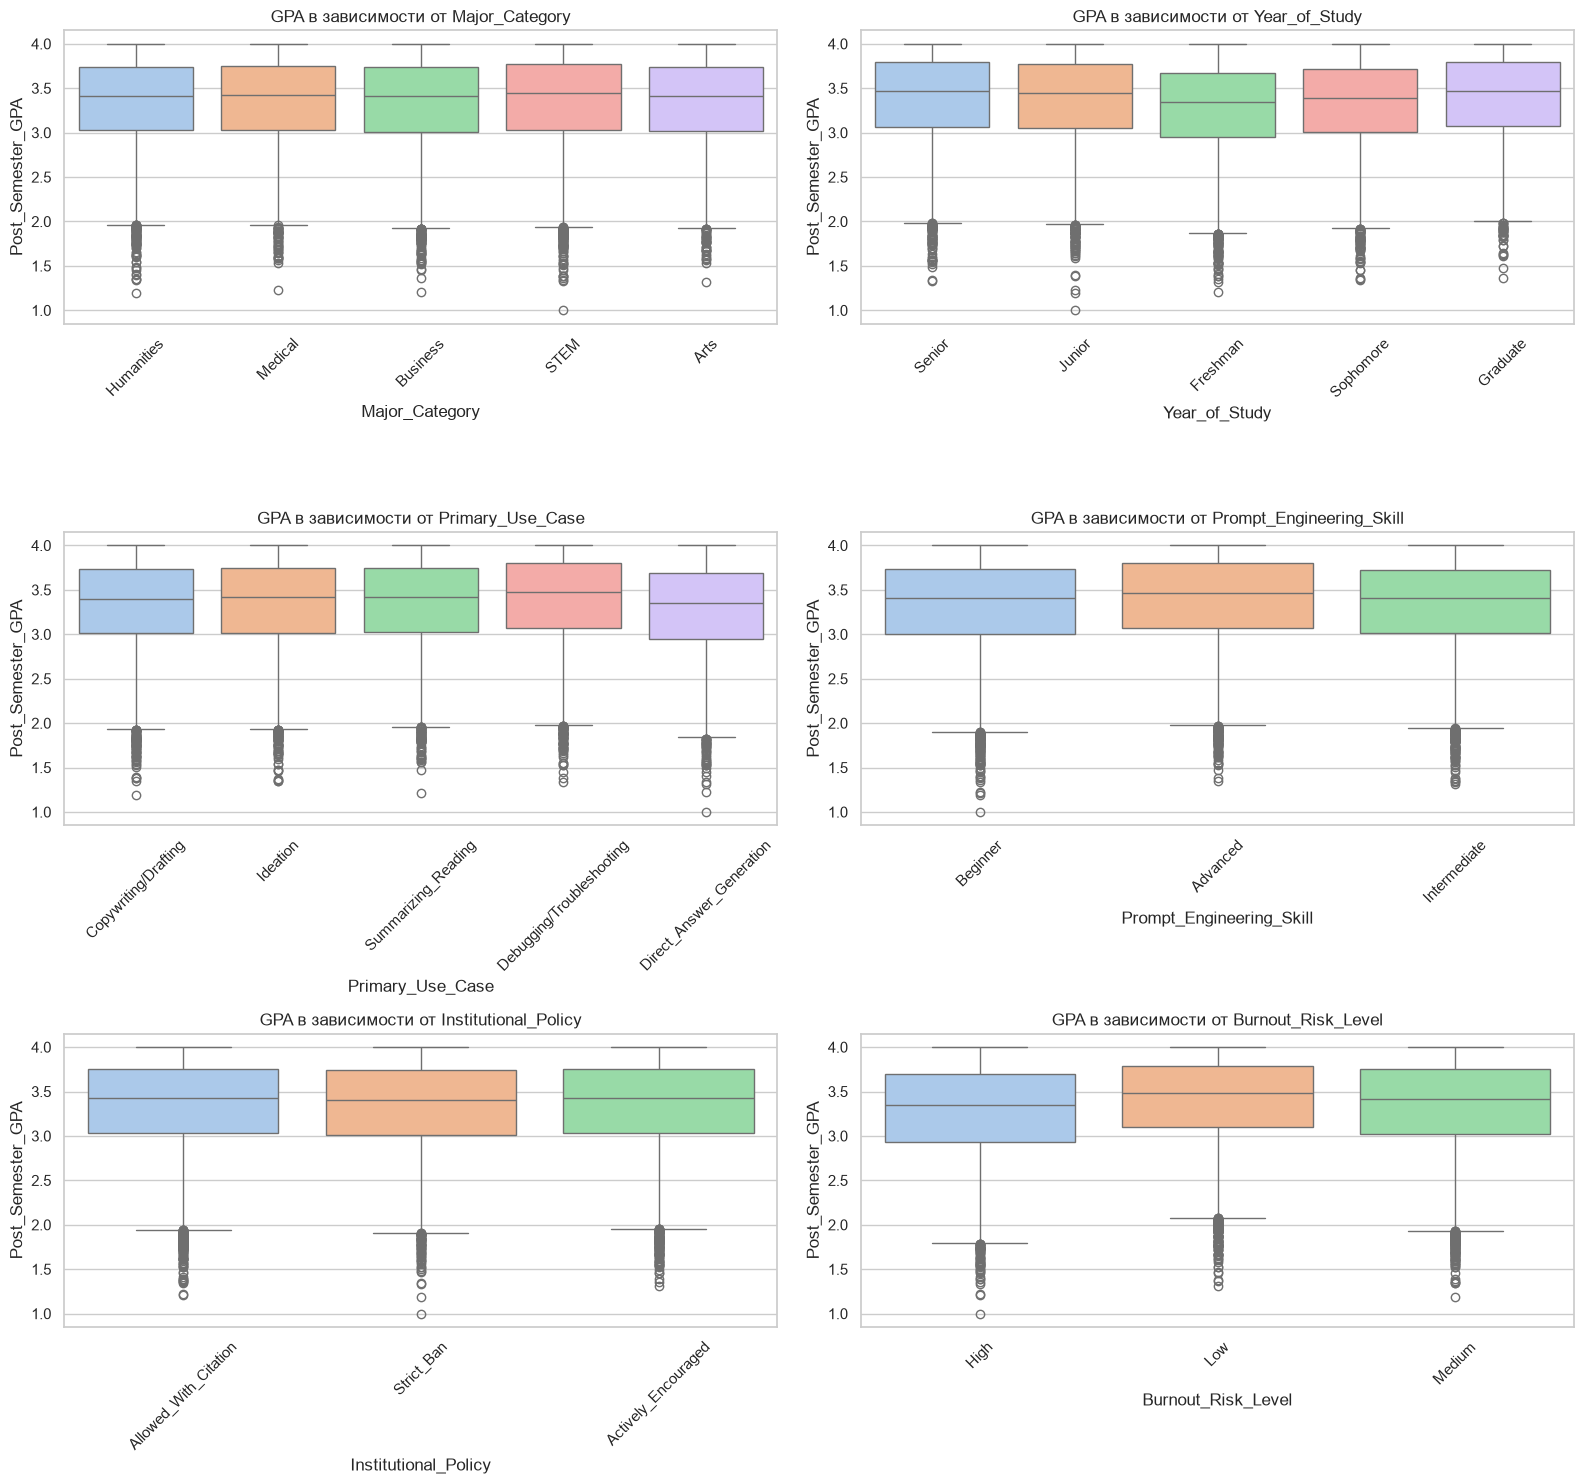

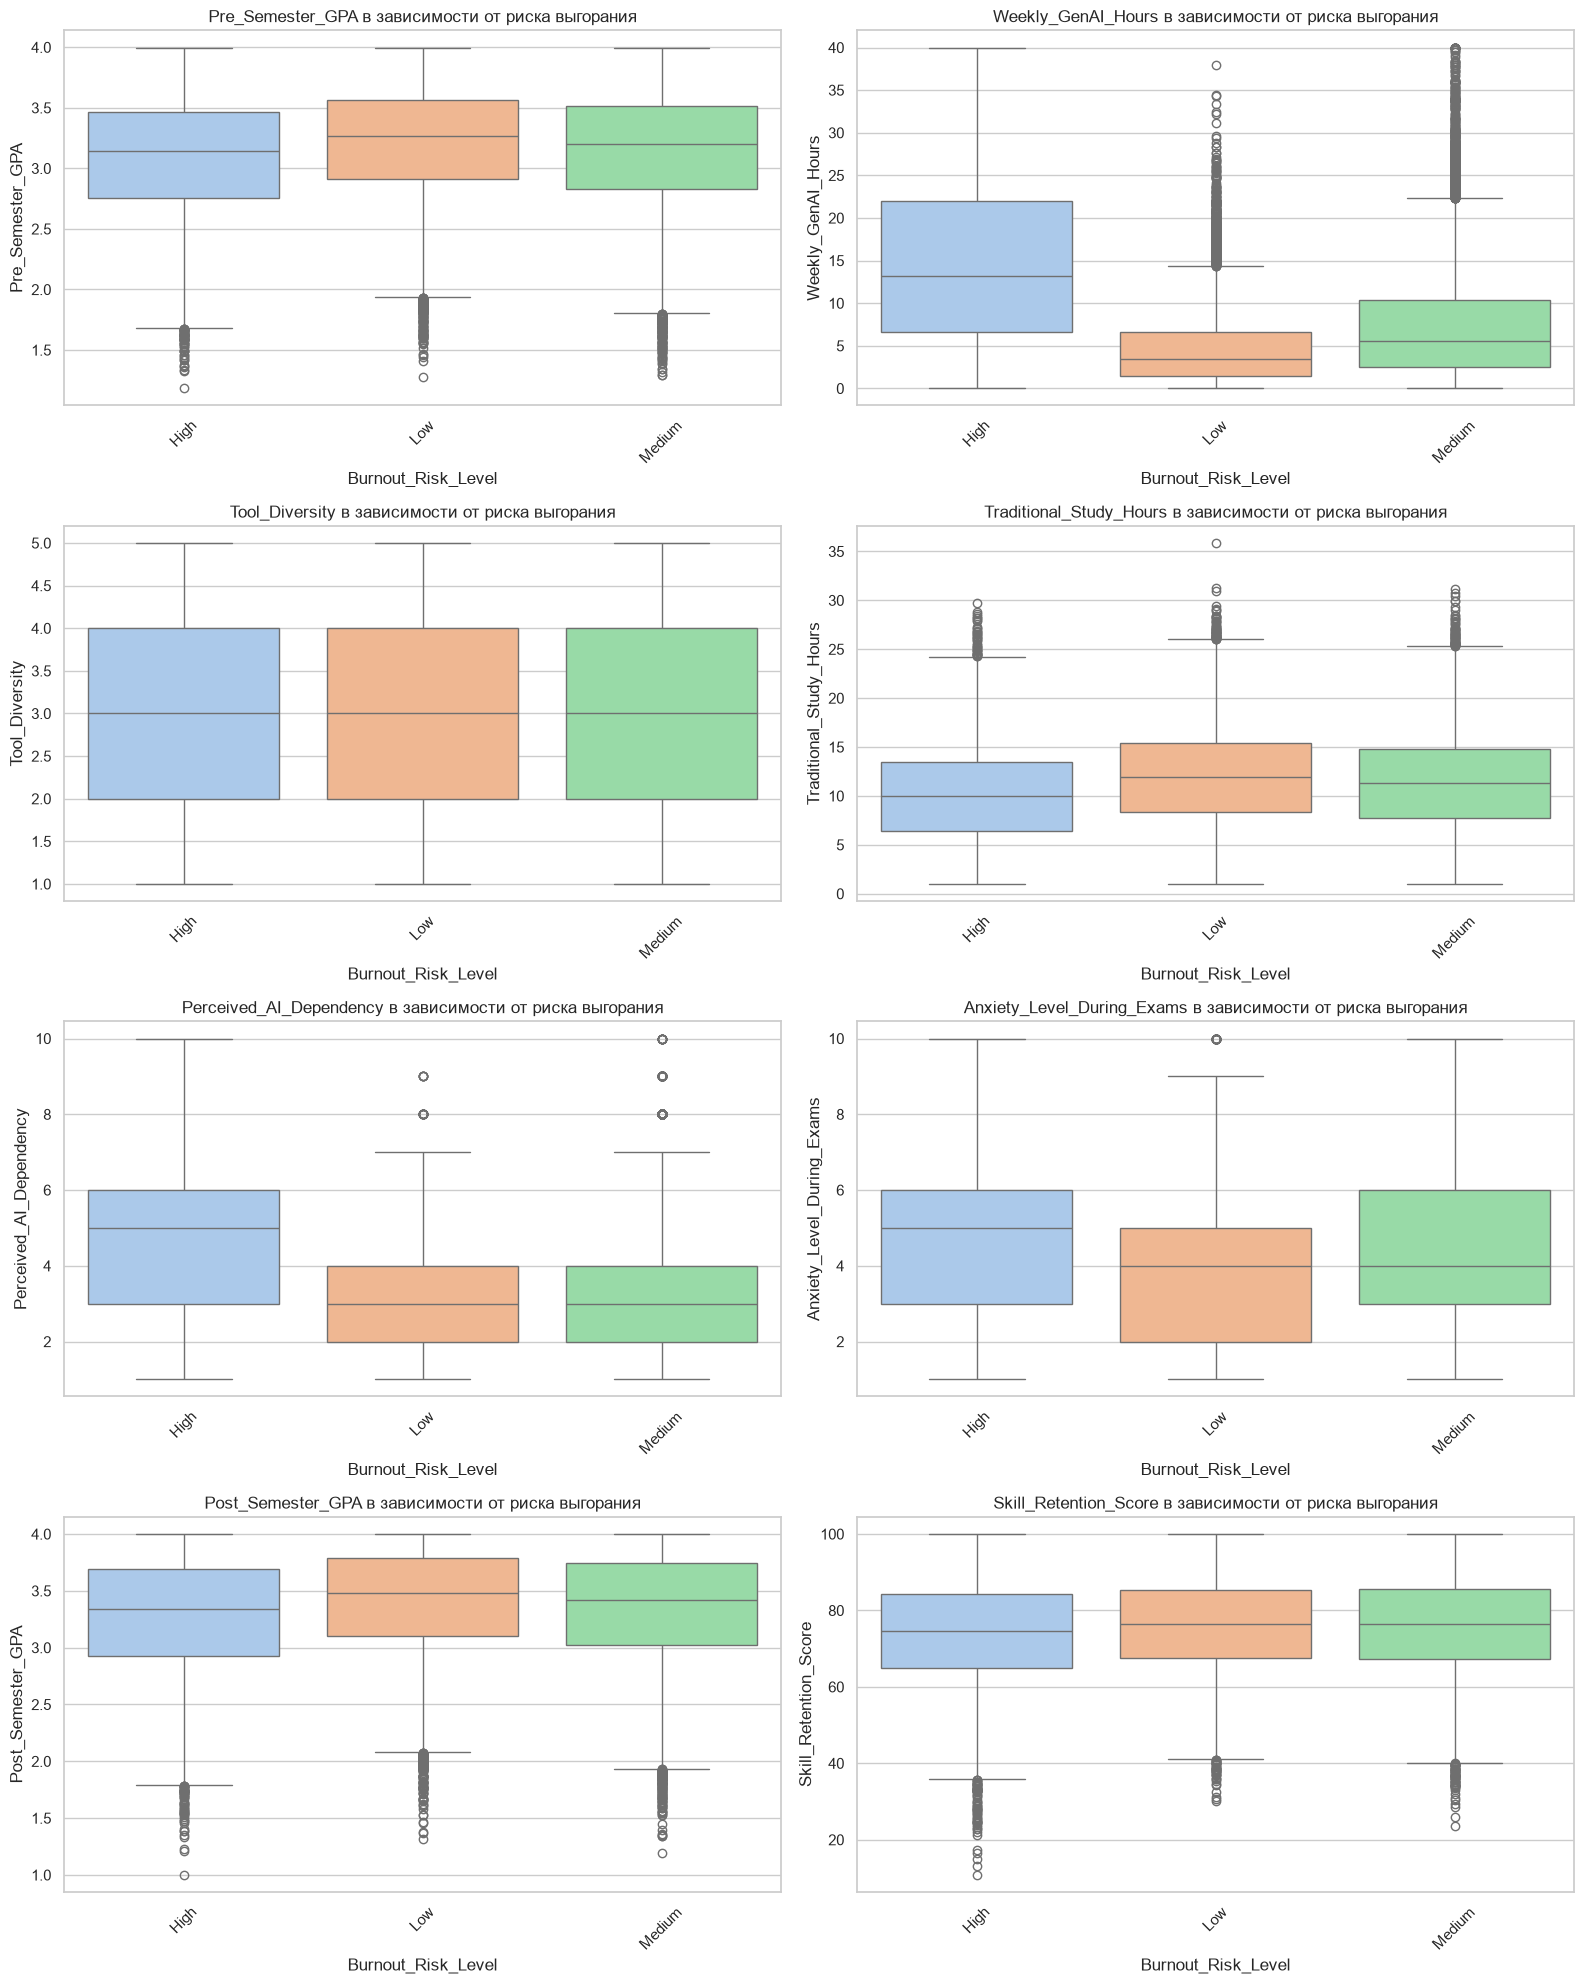

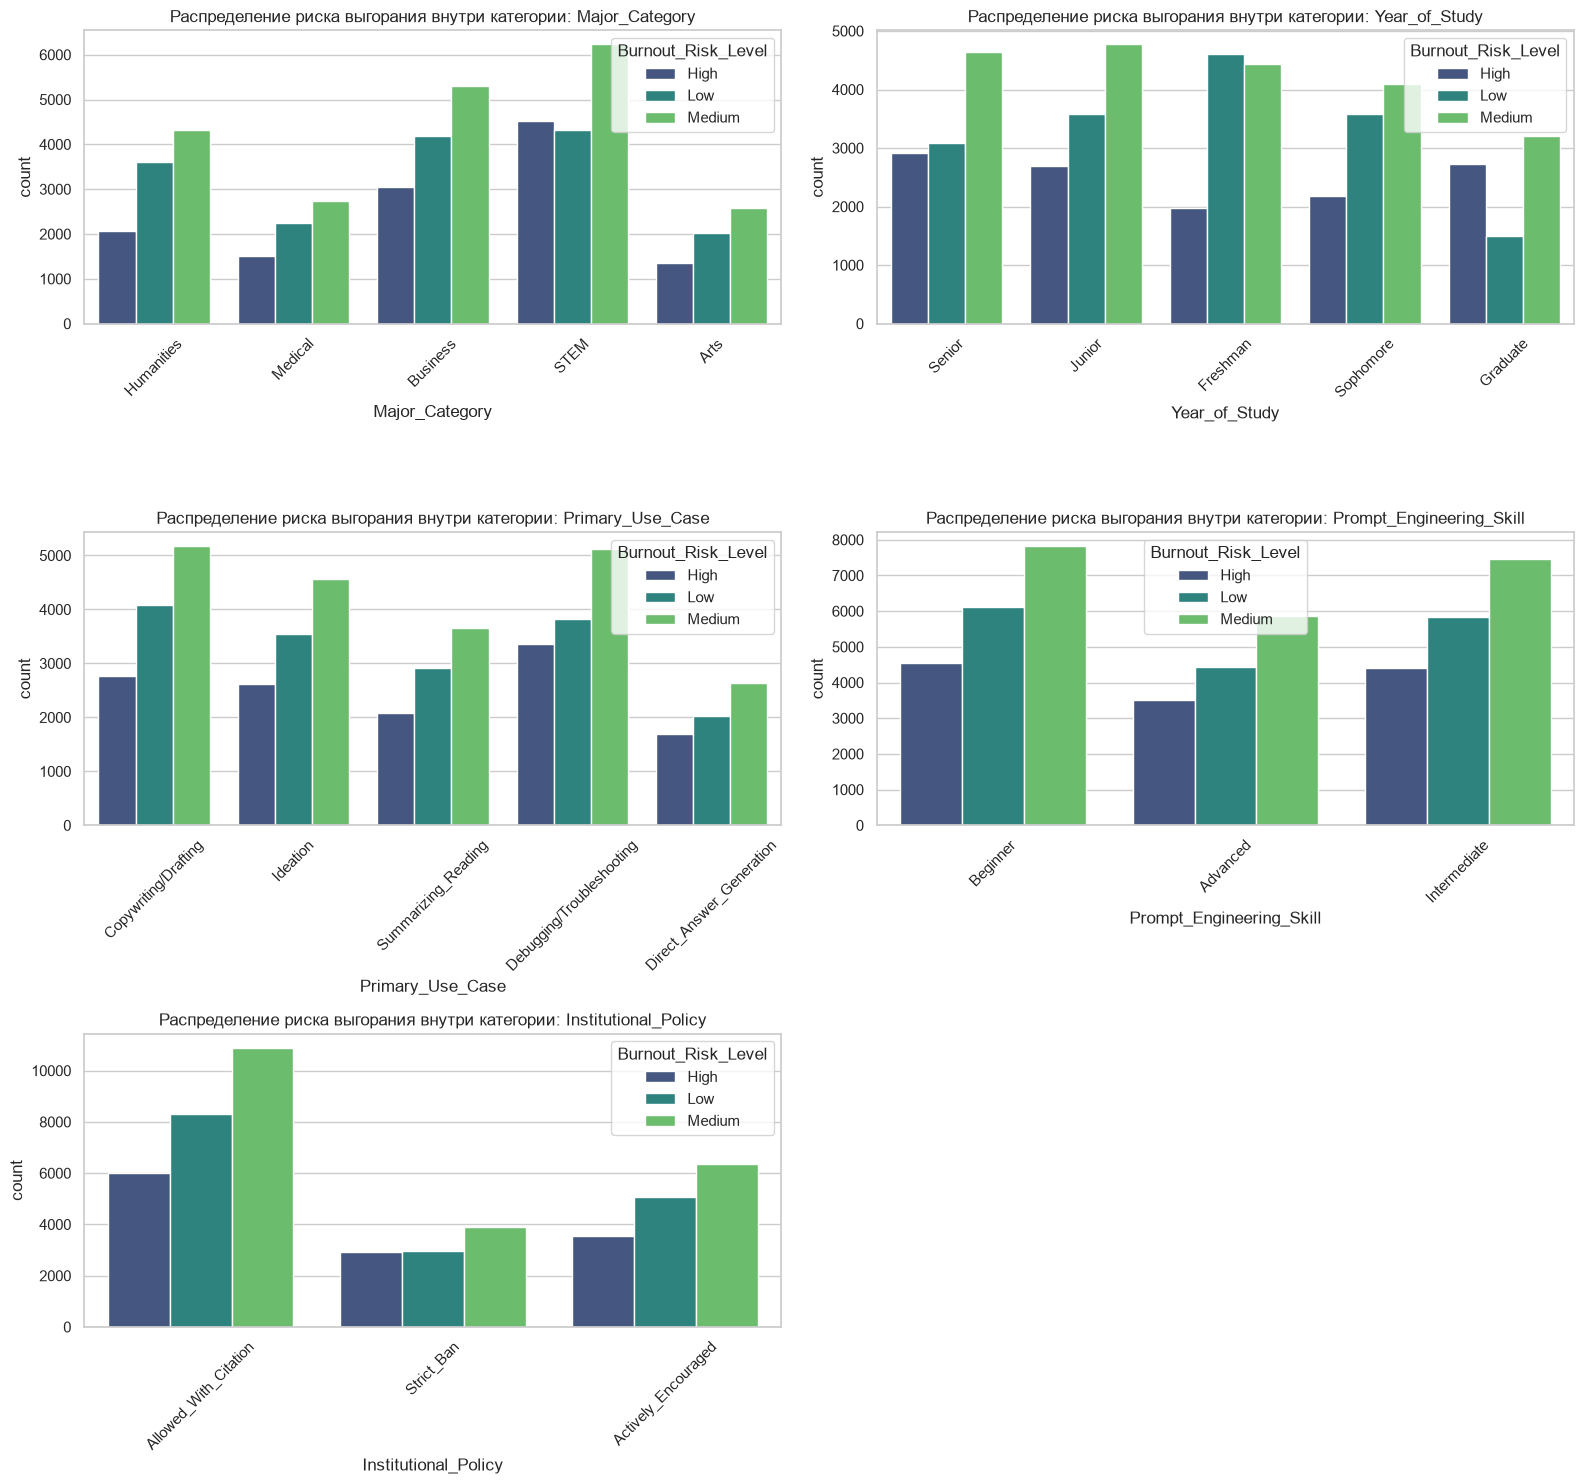

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid")

numeric_cols = dataSet.select_dtypes(include=[np.number]).drop(['Student_ID'], axis=1, errors='ignore').columns.tolist()
df_num = dataSet[numeric_cols]

# -------
plt.figure(figsize=(12, 8))
corr_matrix = df_num.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, center=0)
plt.title('Матрица корреляций числовых признаков', fontsize=14)
plt.show()
# -------


# -------
plt.figure(figsize=(10, 6))
corr_with_gpa = corr_matrix['Post_Semester_GPA'].drop('Post_Semester_GPA').sort_values(ascending=False)

sns.barplot(x=corr_with_gpa.values, y=corr_with_gpa.index, 
            hue=corr_with_gpa.index, palette='viridis', legend=False)
plt.title('Корреляция числовых признаков с Post_Semester_GPA', fontsize=14)
plt.axvline(0, color='red', linestyle='--') 
plt.show()
# ------


# ------
cat_cols_w_brl = dataSet.select_dtypes(include=['str', 'category', 'object']).columns.tolist()

n_cols = len(cat_cols_w_brl)
n_rows = (n_cols + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows))
if n_rows == 1:
    axes = [axes]

for idx, col in enumerate(cat_cols_w_brl):
    row = idx // 2
    col_idx = idx % 2
    ax = axes[row][col_idx] if n_rows > 1 else axes[col_idx]
    
    sns.boxplot(data=dataSet, x=col, y='Post_Semester_GPA', 
                hue=col, palette='pastel', ax=ax, dodge=False, legend=False)
    ax.set_title(f'GPA в зависимости от {col}', fontsize=12)
    ax.tick_params(axis='x', rotation=45)

for idx in range(n_cols, n_rows * 2):
    row = idx // 2
    col_idx = idx % 2
    ax = axes[row][col_idx] if n_rows > 1 else axes[col_idx]
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# -------

n_num = len(numeric_cols)
n_rows_num = (n_num + 1) // 2

fig_num, axes_num = plt.subplots(n_rows_num, 2, figsize=(16, 5 * n_rows_num))
axes_num = axes_num.flatten()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(data=dataSet, x='Burnout_Risk_Level', y=col, 
                hue='Burnout_Risk_Level', palette='pastel', ax=axes_num[idx], dodge=False, legend=False)
    axes_num[idx].set_title(f'{col} в зависимости от риска выгорания', fontsize=12)
    axes_num[idx].tick_params(axis='x', rotation=45)

for idx in range(n_num, len(axes_num)):
    axes_num[idx].set_visible(False)

plt.tight_layout()
plt.show()

cat_cols_wo_brl = dataSet.select_dtypes(include=['str', 'category']).drop(columns=['Burnout_Risk_Level'], errors='ignore').columns.tolist()

n_cat = len(cat_cols_wo_brl)
n_rows_cat = (n_cat + 1) // 2

fig_cat, axes_cat = plt.subplots(n_rows_cat, 2, figsize=(16, 5 * n_rows_cat))
axes_cat = axes_cat.flatten()

for idx, col in enumerate(cat_cols_wo_brl):
    sns.countplot(data=dataSet, x=col, hue='Burnout_Risk_Level', palette='viridis', ax=axes_cat[idx])
    axes_cat[idx].set_title(f'Распределение риска выгорания внутри категории: {col}', fontsize=12)
    axes_cat[idx].tick_params(axis='x', rotation=45)
    axes_cat[idx].legend(title='Burnout_Risk_Level')

for idx in range(n_cat, len(axes_cat)):
    axes_cat[idx].set_visible(False)

plt.tight_layout()
plt.show()
